# Explore Calculated Files
Exploration of pipeline output (`*_recipes_calculated.csv`) — ground truth nutrition vs. AI self-reported values.

In [1]:
gemini_FLite = "../data/gemini_flash_lite_recipes_calculated.csv"
gemini_FLASH = "../data/gemini_flash_recipes_calculated.csv"
Grok_three   = "../data/grok_fast_recipes_calculated.csv"
Grok_four    = "../data/grok4_fast_recipes_calculated.csv"
GPTnano      = "../data/gpt54_nano_recipes_calculated.csv"
GPTmini      = "../data/gpt54_mini_recipes_calculated.csv"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_gemini_lite  = pd.read_csv(gemini_FLite)
df_gemini_Flash = pd.read_csv(gemini_FLASH)
df_grok_three   = pd.read_csv(Grok_three)
df_grok_four    = pd.read_csv(Grok_four)
df_GPT_nano     = pd.read_csv(GPTnano)
df_GPT_mini     = pd.read_csv(GPTmini)

df_liste = [df_gemini_Flash, df_gemini_lite, df_GPT_mini, df_GPT_nano, df_grok_three, df_grok_four]
df_all   = pd.concat(df_liste, ignore_index=True)
print("Total recipes:", len(df_all))
print("Models:", df_all["model"].unique())

Total recipes: 5603
Models: ['gemini_flash' 'gemini_flash_lite' 'gpt54_mini' 'gpt54_nano' 'grok_fast'
 'grok4_fast']


In [3]:
df_grok_three.head()

,recipe_id,model,category,meal_type,title,ingredients_json,instructions,servings,claimed_energy_kcal,claimed_protein_g,...,calculated_who_salt,calculated_who_fibre,claimed_calc_who_score,claimed_calc_who_protein,claimed_calc_who_fat,claimed_calc_who_sat_fat,claimed_calc_who_carbs,claimed_calc_who_sugar,claimed_calc_who_salt,claimed_calc_who_fibre
0,grok_fast_breakfast_1,grok_fast,breakfast,Bagels,Whole Wheat Bagels with Smoked Salmon and Avocado,"[""2 pieces Whole wheat bagels"", ""100 g Smoked ...",Start by slicing the whole wheat bagels in hal...,2,800,40,...,0,0,3,0,0,1,0,1,0,1
1,grok_fast_breakfast_2,grok_fast,breakfast,Bagels,Whole Wheat Bagels with Smoked Salmon and Avocado,"[""2 pieces Whole wheat bagels, pre-made"", ""100...",Start by slicing the whole wheat bagels in hal...,2,780,40,...,0,0,3,0,0,1,0,1,0,1
2,grok_fast_breakfast_3,grok_fast,breakfast,Bagels,Whole Wheat Bagel with Smoked Salmon and Avocado,"[""2 piece Whole wheat bagel, medium"", ""100 g S...",Start by slicing the whole wheat bagels in hal...,2,900,40,...,0,0,3,0,0,1,0,1,0,1
3,grok_fast_breakfast_4,grok_fast,breakfast,Bagels,Whole Grain Bagel with Smoked Salmon and Avocado,"[""2 pieces Whole grain bagels"", ""100 g Smoked ...",Start by slicing the whole grain bagels in hal...,2,900,40,...,0,0,3,0,0,1,0,1,0,1
4,grok_fast_breakfast_5,grok_fast,breakfast,Bagels,Whole Wheat Bagel with Avocado and Smoked Salmon,"[""2 pieces Whole wheat bagels, sliced"", ""100 g...",Start by slicing the whole wheat bagels in hal...,2,920,42,...,0,0,3,0,0,1,0,1,0,1


In [4]:
print("Columns:")
print(list(df_grok_three.columns))

Columns:
['recipe_id', 'model', 'category', 'meal_type', 'title', 'ingredients_json', 'instructions', 'servings', 'claimed_energy_kcal', 'claimed_protein_g', 'claimed_fat_g', 'claimed_carbs_g', 'claimed_saturated_fat_g', 'claimed_sugar_g', 'claimed_fiber_g', 'claimed_salt_g', 'claimed_calcium_mg', 'claimed_iron_mg', 'claimed_magnesium_mg', 'claimed_phosphorus_mg', 'claimed_potassium_mg', 'claimed_zinc_mg', 'claimed_iodine_ug', 'claimed_selenium_ug', 'claimed_vitamin_a_rae_ug', 'claimed_vitamin_d_ug', 'claimed_vitamin_e_mg', 'claimed_vitamin_c_mg', 'claimed_folate_ug', 'claimed_vitamin_b12_ug', 'claimed_vitamin_b1_mg', 'claimed_vitamin_b2_mg', 'claimed_vitamin_b3_mg', 'claimed_vitamin_b6_mg', 'claimed_fsa_score', 'claimed_fsa_category', 'claimed_who_score', 'calculated_calories.quantity', 'calculated_protein', 'calculated_fat', 'calculated_saturated_fatty_acids', 'calculated_carbohydrate', 'calculated_sugar_total', 'calculated_dietary_fibre', 'calculated_sodium_(na)', 'calculated_calciu

## 1. Pipeline summary per model

In [5]:
summary_rows = []

for df in df_liste:
    model_name = df["model"].dropna().astype(str).iloc[0]

    row = {
        "model":               model_name,
        "n_recipes":           len(df),
        "avg_coverage":        df["match_coverage"].mean(),
        "min_coverage":        df["match_coverage"].min(),
        "avg_total_weight_g":  df["total_recipe_weight_g"].mean(),
        "calc_who_mean":       df["calculated_who_score"].mean(),
        "calc_who_std":        df["calculated_who_score"].std(),
        "claimed_who_mean":    df["claimed_who_score"].mean(),
        "calc_fsa_mean":       df["calculated_fsa_score"].mean(),
        "claimed_fsa_mean":    df["claimed_fsa_score"].mean(),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("model").round(3)
display(summary_df)

,n_recipes,avg_coverage,min_coverage,avg_total_weight_g,calc_who_mean,calc_who_std,claimed_who_mean,calc_fsa_mean,claimed_fsa_mean
model,,,,,,,,,
gemini_flash,884,0.997,0.903,1403.440,2.722,1.279,5.861,10.212,4.833
gemini_flash_lite,888,0.997,0.901,1279.030,2.302,1.210,4.793,10.365,6.722
gpt54_mini,976,0.998,0.904,1402.701,2.622,1.314,4.974,10.691,7.126
gpt54_nano,877,0.997,0.902,1369.817,2.334,1.214,4.690,10.675,7.733
grok_fast,1006,1.000,0.932,1298.744,2.419,1.266,5.123,10.360,5.960
grok4_fast,972,0.998,0.902,1277.430,2.850,1.317,4.933,10.174,6.050


## 2. FSA category breakdown — calculated (ground truth)

In [6]:
for df in df_liste:
    model_name = df["model"].iloc[0]
    print(f"\n{model_name} — calculated FSA:")
    print(df["calculated_fsa_category"].value_counts())


gemini_flash — calculated FSA:
calculated_fsa_category
unhealthy    725
moderate     107
healthy       52
Name: count, dtype: int64

gemini_flash_lite — calculated FSA:
calculated_fsa_category
unhealthy    740
moderate     102
healthy       46
Name: count, dtype: int64

gpt54_mini — calculated FSA:
calculated_fsa_category
unhealthy    848
moderate      96
healthy       32
Name: count, dtype: int64

gpt54_nano — calculated FSA:
calculated_fsa_category
unhealthy    773
moderate      81
healthy       23
Name: count, dtype: int64

grok_fast — calculated FSA:
calculated_fsa_category
unhealthy    882
moderate      93
healthy       31
Name: count, dtype: int64

grok4_fast — calculated FSA:
calculated_fsa_category
unhealthy    785
moderate     132
healthy       55
Name: count, dtype: int64


## 3. FSA category breakdown — claimed vs calculated

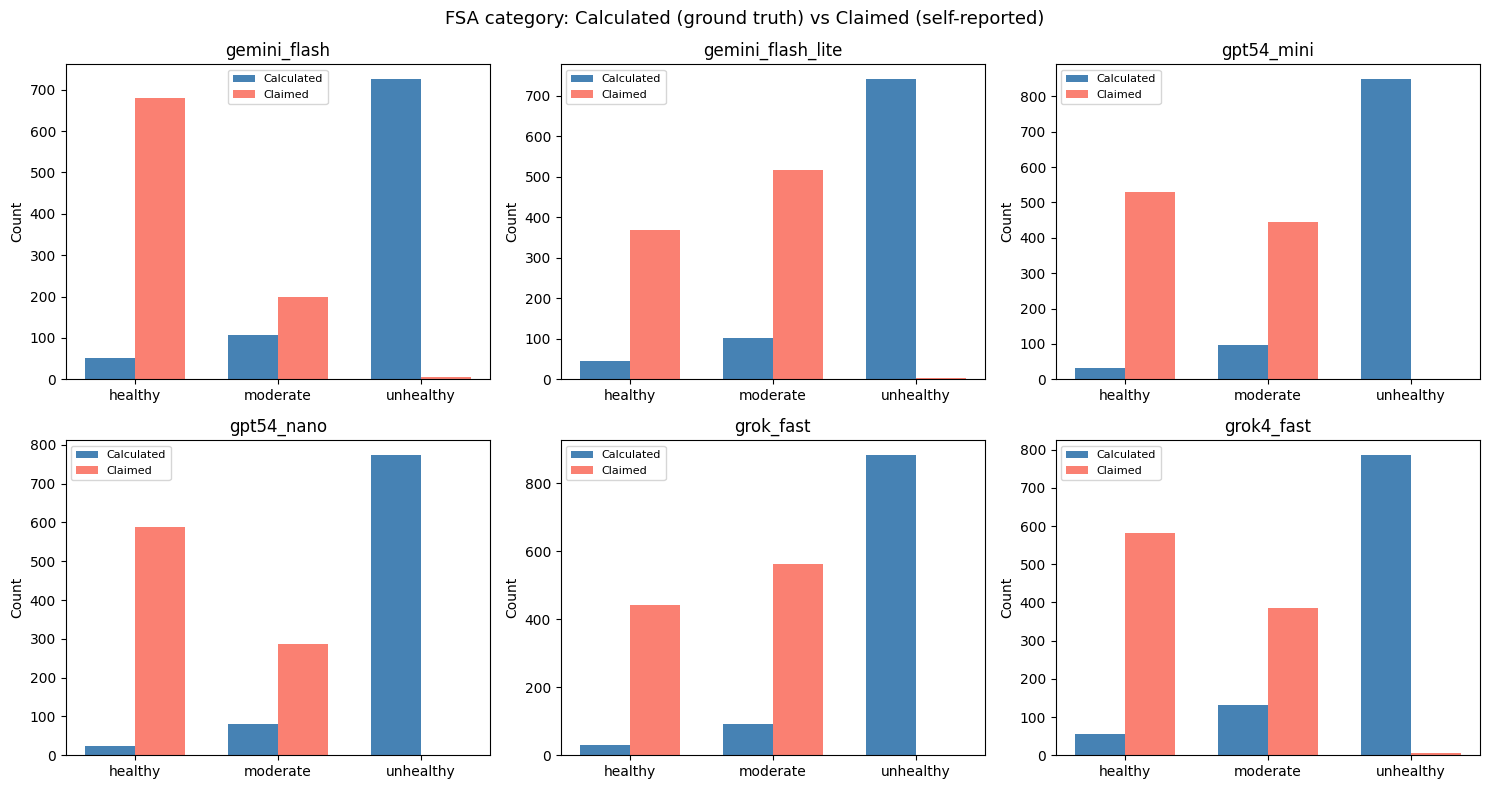

In [7]:
order = ["healthy", "moderate", "unhealthy"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, df in enumerate(df_liste):
    model_name = df["model"].iloc[0]
    ax = axes[i]

    calc_counts    = df["calculated_fsa_category"].str.lower().value_counts().reindex(order, fill_value=0)
    claimed_counts = df["claimed_fsa_category"].str.lower().value_counts().reindex(order, fill_value=0)

    x = np.arange(len(order))
    width = 0.35
    ax.bar(x - width/2, calc_counts.values,   width, label="Calculated", color="steelblue")
    ax.bar(x + width/2, claimed_counts.values, width, label="Claimed",    color="salmon")
    ax.set_title(model_name)
    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("FSA category: Calculated (ground truth) vs Claimed (self-reported)", fontsize=13)
plt.tight_layout()
plt.savefig("figures/fsa_category_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. WHO score — calculated vs claimed, all models

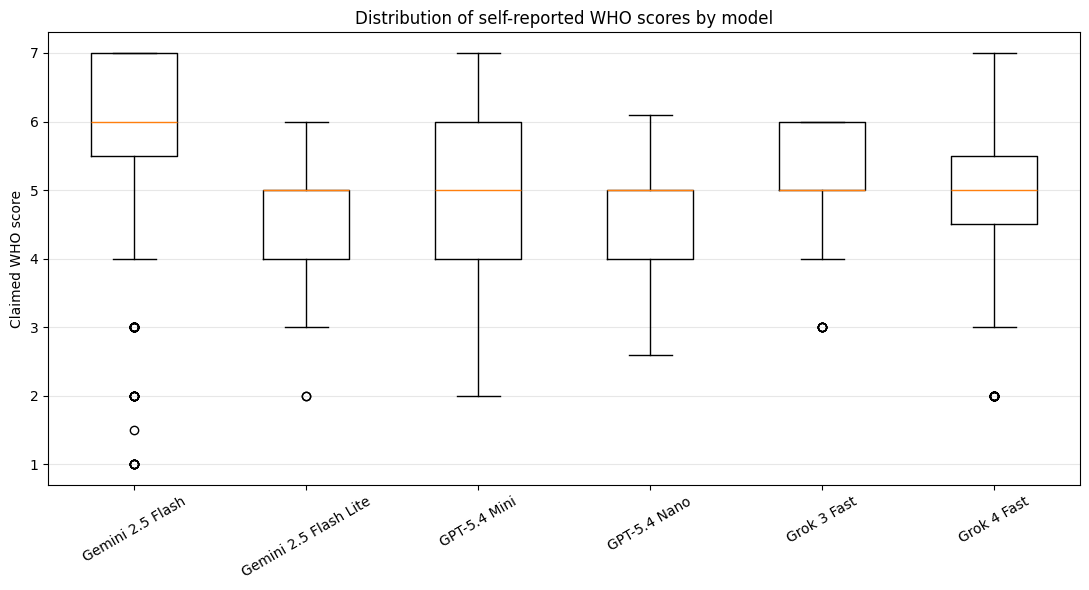

In [8]:
MODEL_LABELS = {
    'gemini_flash':      'Gemini 2.5 Flash',
    'gemini_flash_lite': 'Gemini 2.5 Flash Lite',
    'grok_fast':         'Grok 3 Fast',
    'grok4_fast':        'Grok 4 Fast',
    'gpt54_mini':        'GPT-5.4 Mini',
    'gpt54_nano':        'GPT-5.4 Nano',
}

claimed_who = [df['claimed_who_score'].dropna() for df in df_liste]
models = [df['model'].iloc[0] for df in df_liste]
display_labels = [MODEL_LABELS.get(m, m) for m in models]

fig, ax = plt.subplots(figsize=(11, 6))
ax.boxplot(claimed_who, tick_labels=display_labels)
ax.set_title('Distribution of self-reported WHO scores by model')
ax.set_ylabel('Claimed WHO score')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/who_boxplot_claimed.png', dpi=300, bbox_inches='tight')
plt.show()

## 4b. Self-reported FSA score distribution by model


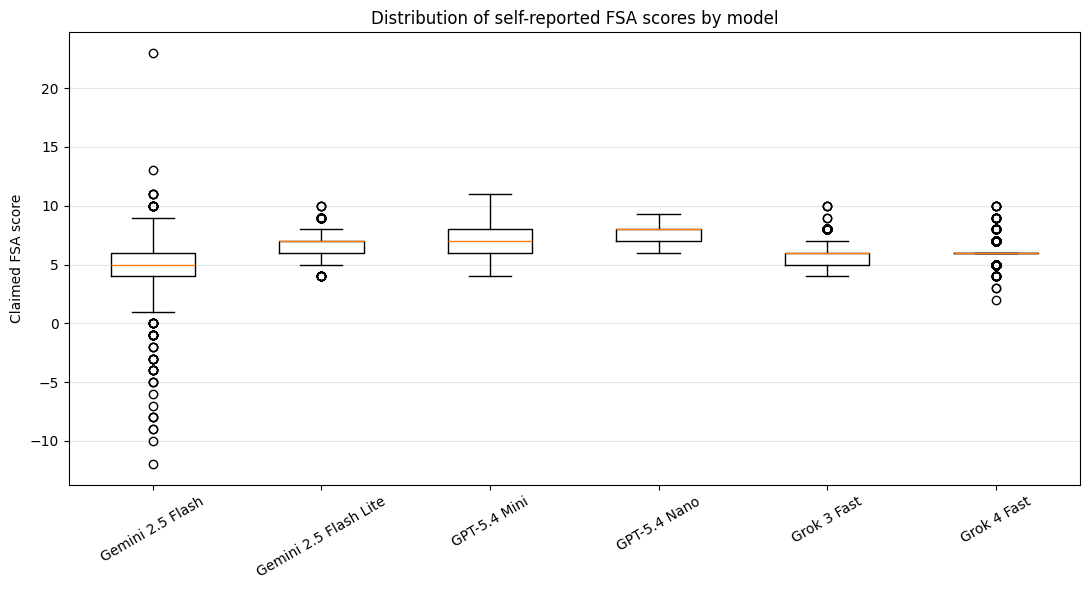

In [9]:
# Calculated FSA is bounded to 4-12 by construction; claimed can go outside that
# range because models sometimes produce nonsense scores.
claimed_fsa = [df['claimed_fsa_score'].dropna() for df in df_liste]
models = [df['model'].iloc[0] for df in df_liste]
display_labels = [MODEL_LABELS.get(m, m) for m in models]

fig, ax = plt.subplots(figsize=(11, 6))
ax.boxplot(claimed_fsa, tick_labels=display_labels)
ax.set_title('Distribution of self-reported FSA scores by model')
ax.set_ylabel('Claimed FSA score')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fsa_boxplot_claimed.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. WHO score mean comparison (bar chart)

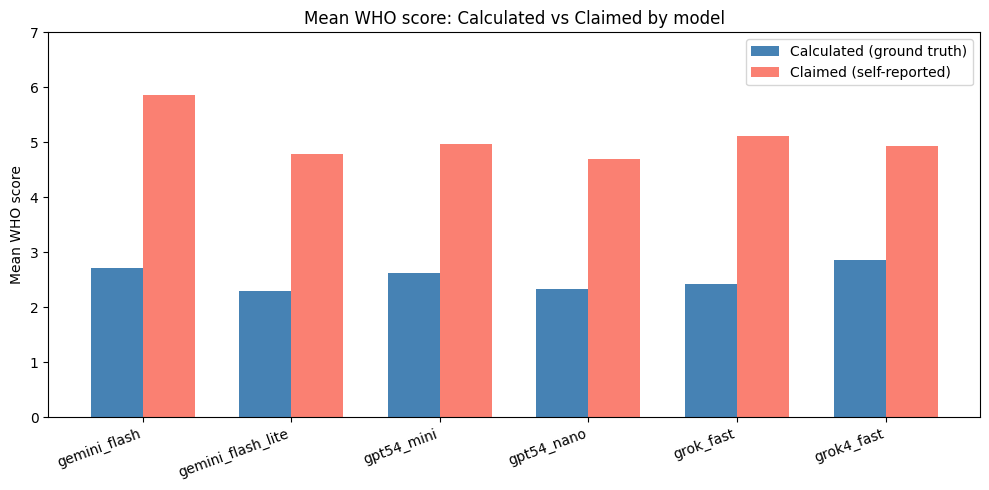

In [10]:
calc_means    = [df["calculated_who_score"].mean() for df in df_liste]
claimed_means = [df["claimed_who_score"].mean()    for df in df_liste]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, calc_means,    width, label="Calculated (ground truth)", color="steelblue")
ax.bar(x + width/2, claimed_means, width, label="Claimed (self-reported)",    color="salmon")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.set_ylabel("Mean WHO score")
ax.set_ylim(0, 7)
ax.set_title("Mean WHO score: Calculated vs Claimed by model")
ax.legend()
plt.tight_layout()
plt.savefig("figures/who_mean_bar.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Scatter: calculated WHO vs claimed WHO (per recipe)

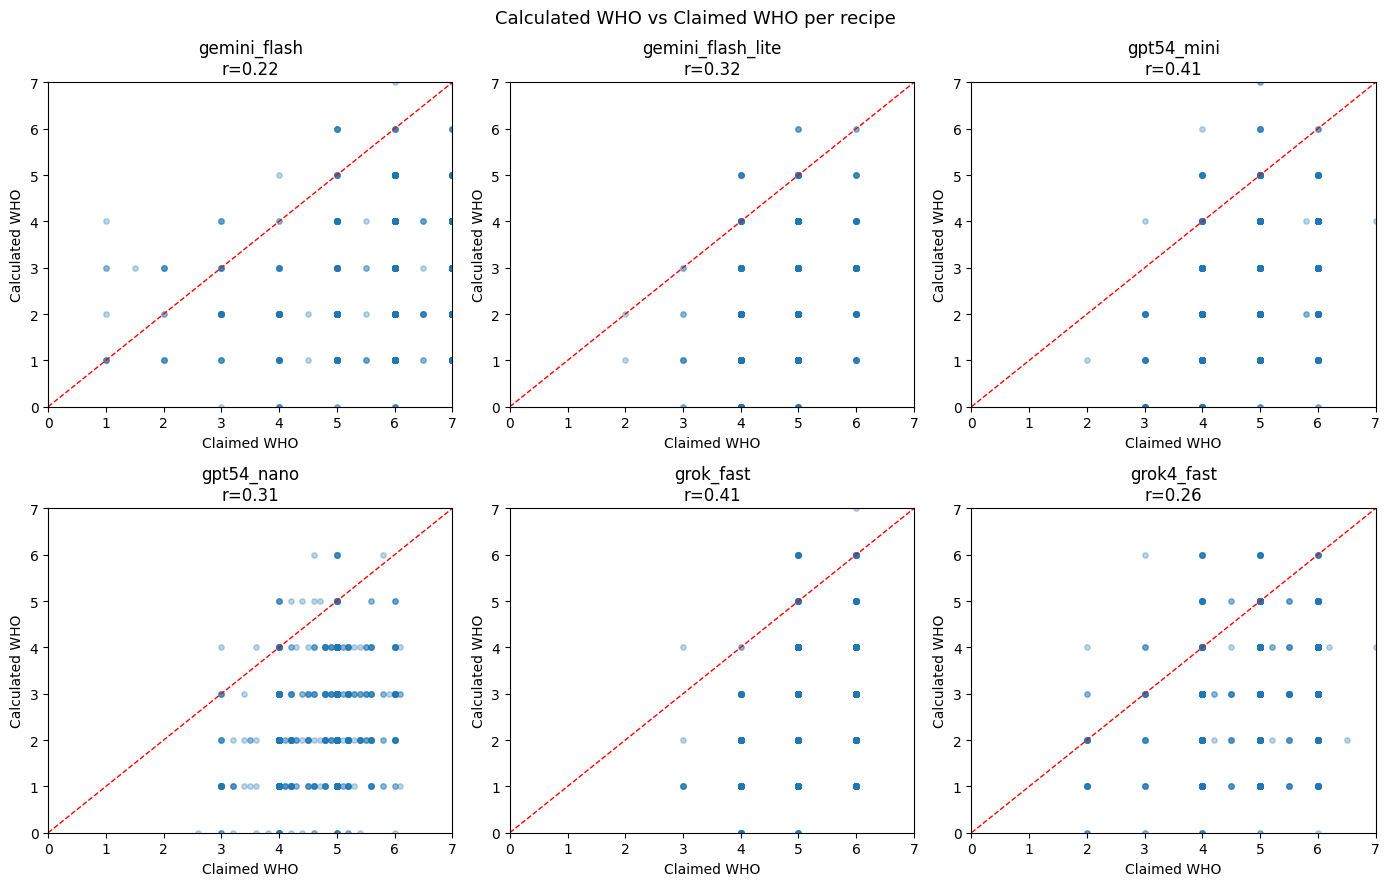

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, df in enumerate(df_liste):
    ax = axes[i]
    model_name = df["model"].iloc[0]
    x = pd.to_numeric(df["claimed_who_score"], errors="coerce")
    y = pd.to_numeric(df["calculated_who_score"], errors="coerce")
    mask = x.notna() & y.notna()
    corr = x[mask].corr(y[mask])
    ax.scatter(x[mask], y[mask], alpha=0.3, s=15)
    ax.plot([0, 7], [0, 7], "r--", lw=1, label="y=x")
    ax.set_xlim(0, 7)
    ax.set_ylim(0, 7)
    ax.set_title(f"{model_name}\nr={corr:.2f}")
    ax.set_xlabel("Claimed WHO")
    ax.set_ylabel("Calculated WHO")

plt.suptitle("Calculated WHO vs Claimed WHO per recipe", fontsize=13)
plt.tight_layout()
plt.savefig("figures/who_scatter_calc_vs_claimed.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Key nutrient comparison: calculated vs claimed (per 100g)

In [12]:
df_all2 = df_all.copy()
w = df_all2["total_recipe_weight_g"].replace(0, np.nan)

df_all2["calc_energy_per100"]    = df_all2["calculated_calories.quantity"] / w * 100
df_all2["claimed_energy_per100"] = df_all2["claimed_energy_kcal"]          / w * 100

df_all2["calc_protein_per100"]    = df_all2["calculated_protein"] / w * 100
df_all2["claimed_protein_per100"] = df_all2["claimed_protein_g"]  / w * 100

df_all2["calc_fat_per100"]    = df_all2["calculated_fat"] / w * 100
df_all2["claimed_fat_per100"] = df_all2["claimed_fat_g"]  / w * 100

df_all2["calc_carbs_per100"]    = df_all2["calculated_carbohydrate"] / w * 100
df_all2["claimed_carbs_per100"] = df_all2["claimed_carbs_g"]         / w * 100

# Calculated sodium is mg; claimed is salt_g → convert via salt_g / 2.5 * 1000.
df_all2["calc_sodium_per100"]    = df_all2["calculated_sodium_(na)"]         / w * 100
df_all2["claimed_sodium_per100"] = (df_all2["claimed_salt_g"] / 2.5 * 1000) / w * 100

nutrients = {
    "Energy (kcal/100g)":   ("calc_energy_per100",   "claimed_energy_per100"),
    "Protein (g/100g)":     ("calc_protein_per100",  "claimed_protein_per100"),
    "Fat (g/100g)":         ("calc_fat_per100",       "claimed_fat_per100"),
    "Carbs (g/100g)":       ("calc_carbs_per100",     "claimed_carbs_per100"),
    "Sodium (mg/100g)":     ("calc_sodium_per100",    "claimed_sodium_per100"),
}

rows = []
for label, (calc_col, claimed_col) in nutrients.items():
    calc_med    = df_all2[calc_col].median()
    claimed_med = df_all2[claimed_col].median()
    corr        = df_all2[[calc_col, claimed_col]].dropna().corr().iloc[0, 1]
    rows.append({"Nutrient": label, "Calc median": round(calc_med, 1), "Claimed median": round(claimed_med, 1), "Ratio calc/claimed": round(calc_med/claimed_med, 2) if claimed_med else None, "Correlation r": round(corr, 2)})

nutrient_df = pd.DataFrame(rows).set_index("Nutrient")
display(nutrient_df)

,Calc median,Claimed median,Ratio calc/claimed,Correlation r
Nutrient,,,,
Energy (kcal/100g),130.4,129.8,1.00,0.76
Protein (g/100g),7.2,6.6,1.10,0.64
Fat (g/100g),4.8,4.7,1.02,0.76
Carbs (g/100g),12.8,14.1,0.90,0.78
Sodium (mg/100g),130.3,109.1,1.19,0.25


## 8. Scatter: calculated vs claimed for key nutrients (all models combined)

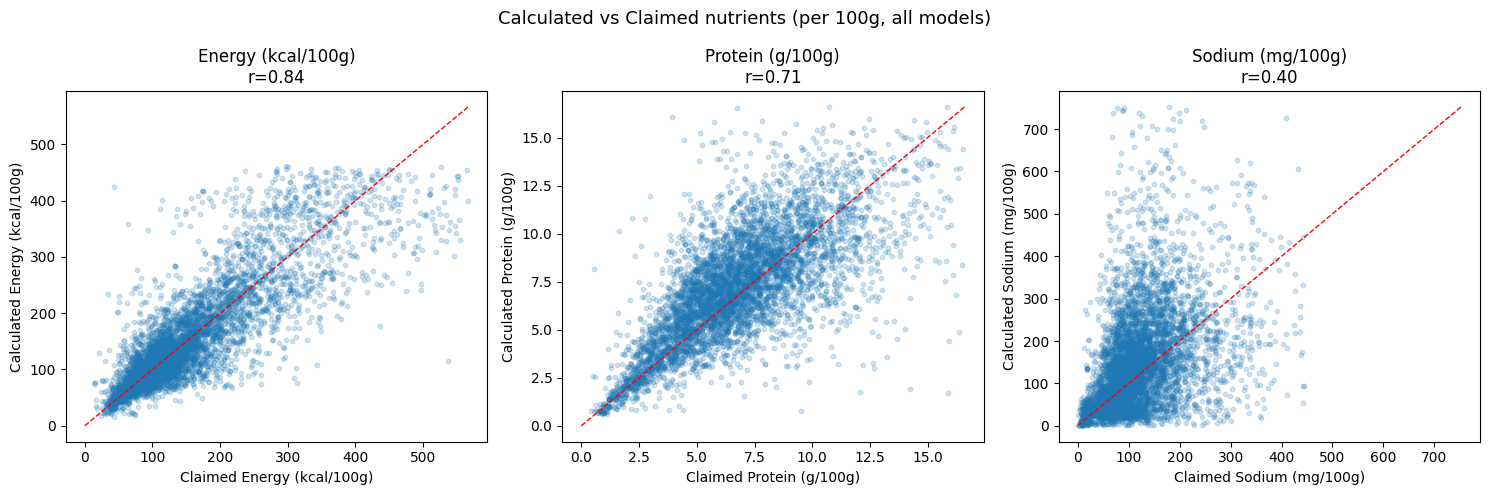

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pairs = [
    ("calc_energy_per100",  "claimed_energy_per100",  "Energy (kcal/100g)"),
    ("calc_protein_per100", "claimed_protein_per100", "Protein (g/100g)"),
    ("calc_sodium_per100",  "claimed_sodium_per100",  "Sodium (mg/100g)"),
]

for ax, (calc_col, claimed_col, label) in zip(axes, pairs):
    x = df_all2[claimed_col].dropna()
    y = df_all2[calc_col].reindex(x.index)
    mask = x.notna() & y.notna() & (x < x.quantile(0.99)) & (y < y.quantile(0.99))
    corr = x[mask].corr(y[mask])
    ax.scatter(x[mask], y[mask], alpha=0.2, s=10)
    lim = max(x[mask].max(), y[mask].max())
    ax.plot([0, lim], [0, lim], "r--", lw=1)
    ax.set_xlabel(f"Claimed {label}")
    ax.set_ylabel(f"Calculated {label}")
    ax.set_title(f"{label}\nr={corr:.2f}")

plt.suptitle("Calculated vs Claimed nutrients (per 100g, all models)", fontsize=13)
plt.tight_layout()
plt.savefig("figures/nutrient_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. FSA score comparison: calculated vs claimed (bar chart per model)

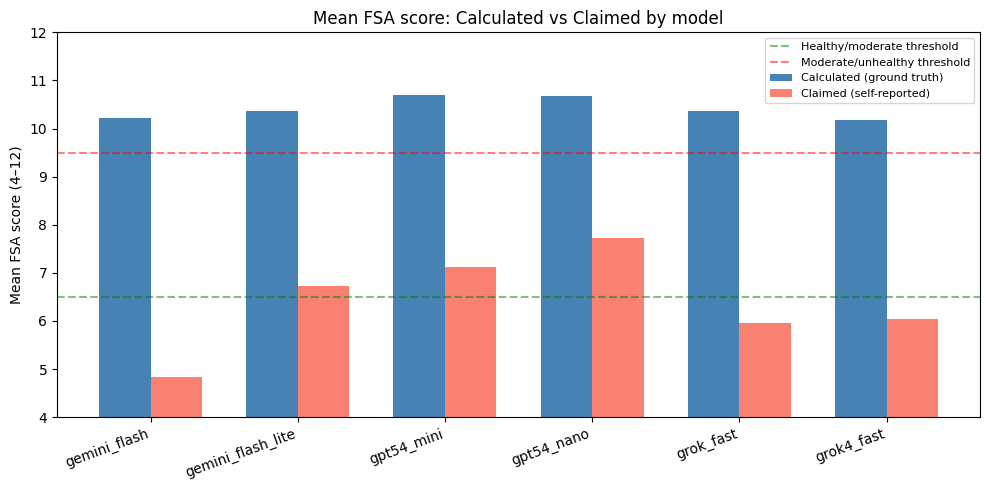

In [14]:
calc_fsa_means    = [df["calculated_fsa_score"].mean() for df in df_liste]
claimed_fsa_means = [df["claimed_fsa_score"].mean()    for df in df_liste]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, calc_fsa_means,    width, label="Calculated (ground truth)", color="steelblue")
ax.bar(x + width/2, claimed_fsa_means, width, label="Claimed (self-reported)",    color="salmon")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.set_ylabel("Mean FSA score (4–12)")
ax.set_ylim(4, 12)
ax.set_title("Mean FSA score: Calculated vs Claimed by model")
ax.axhline(6.5,  linestyle="--", color="green", alpha=0.5, label="Healthy/moderate threshold")
ax.axhline(9.5,  linestyle="--", color="red",   alpha=0.5, label="Moderate/unhealthy threshold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/fsa_mean_bar.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Breakdown by meal category (breakfast / dinner / dessert)

In [15]:
cat_summary = (
    df_all.groupby(["model", "category"])
    .agg(
        n=("recipe_id", "count"),
        calc_who_mean=("calculated_who_score", "mean"),
        calc_fsa_mean=("calculated_fsa_score", "mean"),
    )
    .round(2)
)
display(cat_summary)

n  calc_who_mean  calc_fsa_mean
model             category                                    
gemini_flash      breakfast  144           3.08           9.45
                  dessert    234           2.29          10.51
                  dinner     506           2.82          10.29
gemini_flash_lite breakfast  137           2.52          10.38
                  dessert    246           1.64          11.03
                  dinner     505           2.57          10.04
gpt54_mini        breakfast  144           2.92          10.45
                  dessert    256           1.83          11.18
                  dinner     576           2.90          10.53
gpt54_nano        breakfast  131           2.38          10.73
                  dessert    237           1.84          11.09
                  dinner     509           2.55          10.47
grok4_fast        breakfast  143           2.92          10.03
                  dessert    235           2.70          10.40
                  dinner     594           2.89          10.12
grok_fast         breakfast  150           2.95           9.89
                  dessert    264           1.96          10.50
                  dinner     592           2.49          10.42

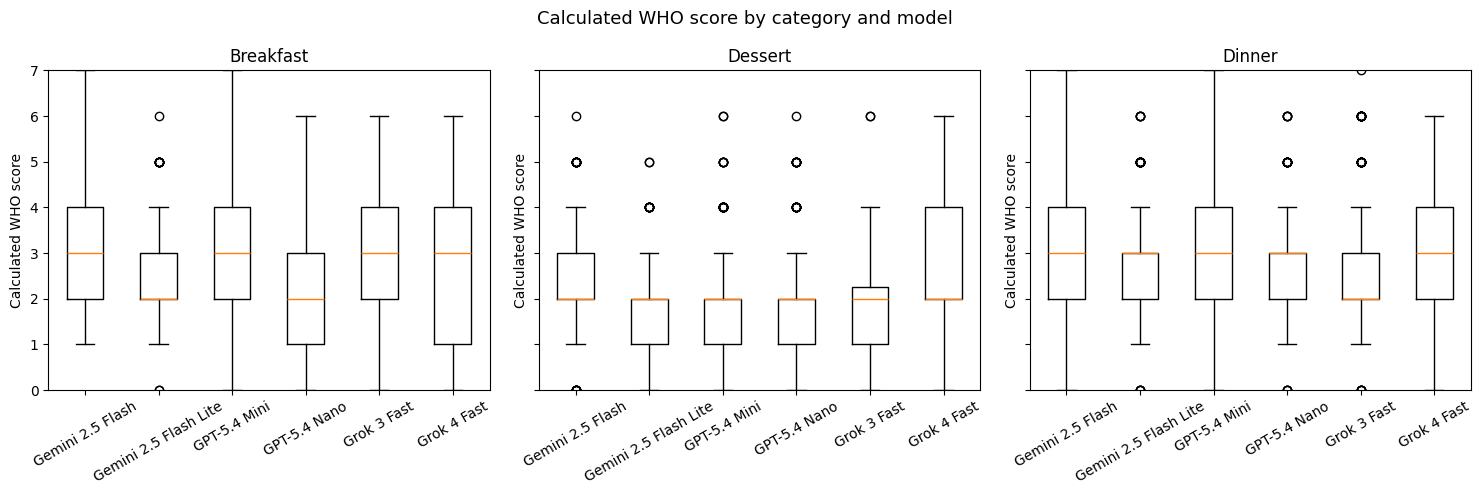

In [16]:
categories = df_all["category"].dropna().unique()

fig, axes = plt.subplots(1, len(categories), figsize=(5 * len(categories), 5), sharey=True)
if len(categories) == 1:
    axes = [axes]

for ax, cat in zip(axes, sorted(categories)):
    sub = df_all[df_all["category"] == cat]
    data = [sub[sub["model"] == m]["calculated_who_score"].dropna() for m in models]
    ax.boxplot(data, tick_labels=[MODEL_LABELS.get(m, m) for m in models])
    ax.set_title(cat.capitalize())
    ax.set_ylabel("Calculated WHO score")
    ax.set_ylim(0, 7)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Calculated WHO score by category and model", fontsize=13)
plt.tight_layout()
plt.savefig("figures/who_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Match coverage distribution

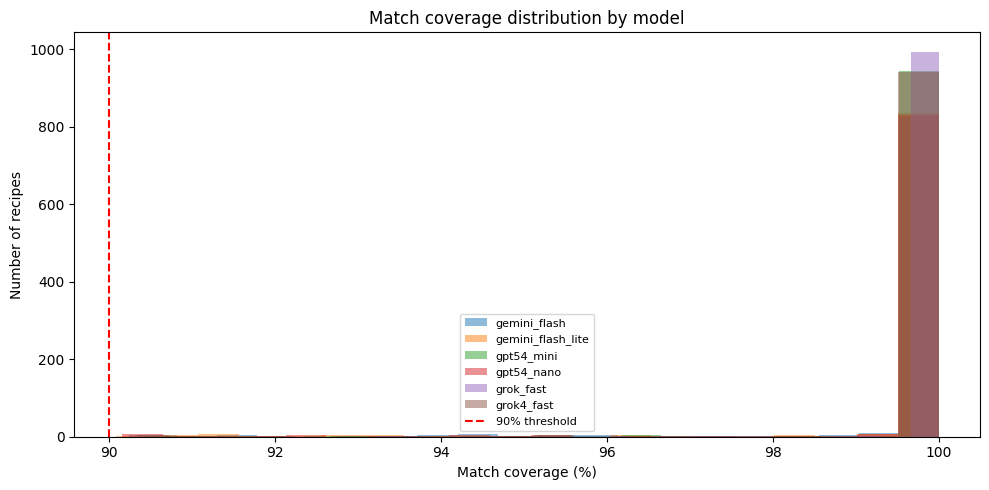

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

for df in df_liste:
    model_name = df["model"].iloc[0]
    ax.hist(df["match_coverage"] * 100, bins=20, alpha=0.5, label=model_name)

ax.axvline(90, color="red", linestyle="--", label="90% threshold")
ax.set_xlabel("Match coverage (%)")
ax.set_ylabel("Number of recipes")
ax.set_title("Match coverage distribution by model")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/coverage_hist.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. FSA agreement: calculated vs claimed

In [18]:
rows = []
for df in df_liste:
    model_name = df["model"].iloc[0]
    n = len(df)
    agree_self = (df["calculated_fsa_category"].str.lower() == df["claimed_fsa_category"].str.lower()).sum()
    agree_calc = (df["calculated_fsa_category"].str.lower() == df["claimed_calc_fsa_category"].str.lower()).sum()
    rows.append({
        "model":                         model_name,
        "n_recipes":                     n,
        "agree_calc_vs_self_reported":   f"{agree_self}/{n} ({agree_self/n:.0%})",
        "agree_calc_vs_claimed_recalc":  f"{agree_calc}/{n} ({agree_calc/n:.0%})",
    })

agreement_df = pd.DataFrame(rows).set_index("model")
display(agreement_df)

,n_recipes,agree_calc_vs_self_reported,agree_calc_vs_claimed_recalc
model,,,
gemini_flash,884,64/884 (7%),728/884 (82%)
gemini_flash_lite,888,72/888 (8%),719/888 (81%)
gpt54_mini,976,34/976 (3%),854/976 (88%)
gpt54_nano,877,37/877 (4%),767/877 (87%)
grok_fast,1006,50/1006 (5%),892/1006 (89%)
grok4_fast,972,64/972 (7%),840/972 (86%)
